# AUTHOR
## Nikhil Reddy Battpati
### EID: nb29255


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# PART 1 - OPTION C (Damped Mechanical System)

stepSizes = np.array([0.01,0.05,0.1, 0.15, 0.5])
w = 8.5
zeta = 0.56
y_init = -1
y_init_prime = 0 

def ForwardEuler(stepSizes, w,zeta,y_init, y_init_prime):
    #Initialize Matrix Representing Dynamics
    A1 = np.array([0, -w**2])
    A2 = np.array([1, -2*zeta*w])
    A = np.column_stack((A1,A2)) 

    #Initialize Arrays That Will Be Returned
    submit_y_vals = []
    submit_y_prime_vals = []
    submit_x_vals = []


    for stepSize in stepSizes:
        x_vals = np.arange(0, 80+stepSize, stepSize)
        #Initial Conditions
        y_vals = np.array([y_init])
        y_prime_vals = np.array([y_init_prime])

        # Forward Euler Integration Scheme
        for i in range(x_vals.shape[0]-1):
            y_state = np.array([y_vals[i], y_prime_vals[i]])
            y_vals = np.append(y_vals, y_vals[i] + stepSize * (A[0] @ y_state) )
            y_prime_vals = np.append(y_prime_vals, y_prime_vals[i] + stepSize * (A[1] @ y_state))


        submit_y_vals.append(y_vals)
        submit_y_prime_vals.append(y_prime_vals)
        submit_x_vals.append(x_vals)

    


    return np.array([submit_y_vals, submit_y_prime_vals, submit_x_vals],dtype=object)


def RungeKutta(stepSizes, w,zeta,y_init, y_init_prime):
    #Initialize Matrix Representing Dynamics
    A1 = np.array([0, -w**2])
    A2 = np.array([1, -2*zeta*w])
    A = np.column_stack((A1,A2)) 

    #Initialize Arrays That Will Be Returned
    submit_y_vals = []
    submit_y_prime_vals = []
    submit_x_vals = []
   

    for stepSize in stepSizes:

        x_vals = np.arange(0, 80+stepSize, stepSize)

        #Initial Conditions
        y_vals = np.array([y_init])
        y_prime_vals = np.array([y_init_prime])

        # Runge-Kutta Integration Scheme
        for i in range(x_vals.shape[0]-1):
            y_state = np.array([y_vals[i], y_prime_vals[i]])
            k1 = A @ y_state
            k2 = A @ (y_state + 0.5 * stepSize * k1)
            k3 = A @ (y_state + 0.5 * stepSize * k2)
            k4 = A @ (y_state + stepSize * k3)
            y_vals = np.append(y_vals, y_vals[i] + (stepSize / 6) * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0]) )
            y_prime_vals = np.append(y_prime_vals, y_prime_vals[i] + (stepSize / 6) * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1]) )


        submit_y_vals.append(y_vals)
        submit_y_prime_vals.append(y_prime_vals)
        submit_x_vals.append(x_vals)
    


    return np.array([submit_y_vals, submit_y_prime_vals, submit_x_vals],dtype=object)


def AnalyticalSolution(stepSizes, w, zeta, y_init, y_init_prime):
    #Damped Natural Frequency (Underdamped case since zeta < 1)
    wd = w * np.sqrt(1 - zeta**2)

    #Coefficients Derived From Initial Conditions
    A_coef = y_init
    B_coef = (y_init_prime + zeta * w * y_init) / wd

    #Initialize Arrays That Will Be Returned
    submit_y_vals = []
    submit_y_prime_vals = []
    submit_x_vals = []

    for stepSize in stepSizes:
        x_vals = np.arange(0, 80+stepSize, stepSize)

        # Analytical Solution: y(t) = e^(-zeta*w*t) * (A*cos(wd*t) + B*sin(wd*t))
        envelope = np.exp(-zeta * w * x_vals) # Envolope that the amplitude is decaying with respect to
        y_vals = envelope * (A_coef * np.cos(wd * x_vals) + B_coef * np.sin(wd * x_vals))
        y_prime_vals = (-zeta * w * envelope * (A_coef * np.cos(wd * x_vals) + B_coef * np.sin(wd * x_vals))
                        + envelope * (-A_coef * wd * np.sin(wd * x_vals) + B_coef * wd * np.cos(wd * x_vals)))

        submit_y_vals.append(y_vals)
        submit_y_prime_vals.append(y_prime_vals)
        submit_x_vals.append(x_vals)

    return np.array([submit_y_vals, submit_y_prime_vals, submit_x_vals], dtype=object)





for stepSize in stepSizes:
    
    y_vals_euler, y_prime_vals_euler, x_vals_euler = ForwardEuler([stepSize], w,zeta,y_init, y_init_prime)
    y_vals_rk, y_prime_vals_rk, x_vals_rk = RungeKutta([stepSize], w,zeta,y_init, y_init_prime)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    axes[0].plot(x_vals_euler[0], y_vals_euler[0], label='Forward Euler')
    axes[0].plot(x_vals_rk[0], y_vals_rk[0], label='Runge-Kutta')
    axes[0].set_title(f'Y(t) - Step Size: {stepSize}')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('y(t)')
    axes[0].legend()

    axes[1].plot(x_vals_euler[0], y_prime_vals_euler[0], label='Forward Euler')
    axes[1].plot(x_vals_rk[0], y_prime_vals_rk[0], label='Runge-Kutta')
    axes[1].set_title(f'V(t) - Step Size: {stepSize}')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('v(t)')
    axes[1].legend()
    
    axes[2].plot(y_vals_euler[0], y_prime_vals_euler[0], label='Forward Euler')
    axes[2].plot(y_vals_rk[0], y_prime_vals_rk[0], label='Runge-Kutta')
    axes[2].set_title(f'Phase Plot - Step Size: ' + str(stepSize))
    axes[2].set_xlabel('y(t)')
    axes[2].set_ylabel('v(t)')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    plt.tight_layout()
    plt.show()

#Initialize Arrays To Store Max Errors For Convergence Plot
euler_max_errors = []
rk_max_errors = []

for stepSize in stepSizes:

    y_vals_euler, y_prime_vals_euler, x_vals_euler = ForwardEuler([stepSize], w, zeta, y_init, y_init_prime)
    y_vals_rk, y_prime_vals_rk, x_vals_rk = RungeKutta([stepSize], w, zeta, y_init, y_init_prime)
    y_vals_exact, y_prime_vals_exact, x_vals_exact = AnalyticalSolution([stepSize], w, zeta, y_init, y_init_prime)

    # Compute Absolute Error At Each Time Step
    error_euler = np.abs(y_vals_euler[0] - y_vals_exact[0])
    error_rk = np.abs(y_vals_rk[0] - y_vals_exact[0])

    # Store Max Errors For Log-Log Convergence Plot
    euler_max_errors.append(np.max(error_euler))
    rk_max_errors.append(np.max(error_rk))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].plot(x_vals_euler[0], y_vals_euler[0], label='Forward Euler')
    axes[0].plot(x_vals_rk[0], y_vals_rk[0], label='Runge-Kutta')
    axes[0].plot(x_vals_exact[0], y_vals_exact[0], '--', label='Analytical', color='black')
    axes[0].set_title(f'Y(t) vs Analytical - Step Size: {stepSize}')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('y(t)')
    axes[0].legend()

    axes[1].semilogy(x_vals_euler[0], error_euler, label='Forward Euler Error')
    axes[1].semilogy(x_vals_rk[0], error_rk, label='Runge-Kutta Error')
    axes[1].set_title(f'Absolute Error - Step Size: {stepSize}')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('|y_numerical - y_analytical|')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


euler_max_errors = np.array(euler_max_errors, dtype=float)
rk_max_errors = np.array(rk_max_errors, dtype=float)

# Compute Convergence Slopes Via Linear Fit w/ loglog
euler_slope = np.polyfit(np.log(stepSizes), np.log(euler_max_errors), 1)[0]
rk_slope = np.polyfit(np.log(stepSizes), np.log(rk_max_errors), 1)[0]

# Log-Log Convergence Plot
plt.figure(figsize=(10, 7))
plt.loglog(stepSizes, euler_max_errors, 'o-', label=f'Forward Euler (slope ≈ {euler_slope:.2f})')
plt.loglog(stepSizes, rk_max_errors, 's-', label=f'Runge-Kutta (slope ≈ {rk_slope:.2f})')

# Reference Slopes (Anchored At Smallest Step Size)
plt.loglog(stepSizes, euler_max_errors[0] * (stepSizes / stepSizes[0])**1, '--', label='O(h) reference')
plt.loglog(stepSizes, rk_max_errors[0] * (stepSizes / stepSizes[0])**4, '--', label='O(h^4) reference')

plt.title('Convergence Rates: Error vs Step Size')
plt.xlabel('Step Size (h)')
plt.ylabel('Max Absolute Error')
plt.legend()
plt.show()

print(f"Forward Euler empirical convergence rate: {euler_slope:.3f} (expected ≈ 1)")
print(f"Runge-Kutta empirical convergence rate: {rk_slope:.3f} (expected ≈ 4)")

h_max_euler_analytical = 2 * zeta / w
h_max_rk_analytical = 2.78 / w

print(f"Analytical max stable step size (Forward Euler): h <= " + str(h_max_euler_analytical))
print(f"Analytical max stable step size (RK4):           h <= " + str(h_max_rk_analytical))


# CITATIONS (Part 1)
# AI 
# I used Claude Opus 4.6 to answer this prompt 
# "
# I need to plot out my y(t) and v(t), can you plot them over time and also add a phase plot of v(t) vs y(t) for each step size"
# "
# It produced the code for the plots above. 
# The reason I wanted it to do this is because I didn't know how to get the phase plot to work well, and to have things be formatted so nicely

# I used Claude Opus 4.7 to answer this prompt
# "Caclulate the analytical solution to this diff eq in numpy.""
# It produced the analytical solution function (closed-form for the underdamped
# harmonic oscillator)
# The reason I wanted it to do this is because I didn't want to go through and do the eigendecomposition by hand (I don't think that was the intent of the assignment)

# I used Claude Opus 4.7 to answer this prompt
# "Please rewrite the code to do the plotting for the values that have been calculated with the step size error analyses, also what's the form for max analyic stability for RK4 and FE for this system"
# It produced the code to do the plotting of the error analyses in the log scale, and making it look nicer
# The reason I wanted it to do this is because I didn't want to write the plotting code (not particularily interesting to me)


# (Normal) Sources Used:
# https://www.w3schools.com/python/matplotlib_intro.asp























# Part One - Option C (Damped Mechanical Oscillator)
## Intro & Model Selection

My real world system is analyzing how a vehicle suspension responds to compression/expansion and progresses through time.

The governing second order equation is:
$$\frac{d^2 y}{dt^2} + 2\zeta\omega\frac{dy}{dt} + \omega^2 y = 0$$

System of First Order Differential Equations
$$
\begin{bmatrix}
\dot{y}\\
\dot{v}
\end{bmatrix}
=
\begin{bmatrix}
0 & 1\\
-\omega^{2} & -2\zeta\omega
\end{bmatrix}
\begin{bmatrix}
y\\
v
\end{bmatrix}
$$

Some background of what each parameter means:

- **Natural Frequency (ω)** is the undamped oscillation frequency of the suspension system, measured in radians per second. It describes how fast the suspension would bounce up and down if there were no damping (no shock absorber). A higher natural frequency means a stiffer spring system.

- **Damping Ratio (ζ)** is a dimensionless number that measures how much energy is dissipated by the shock absorber relative to the natural oscillation. 

- **Damping Coefficient (2ζω)** represents the actual damping force that is proportional to the velocity of the suspension. This is directly related to how much resistance the shock absorber provides as the suspension moves.



## Parameter Research

First I would like to state some prerequisite knowledge for researching good paramtervalues for omega (angular frequency) and zeta (damping ratio).

$$\omega = \sqrt{\frac{k}{m}}$$


$$\zeta = \frac{c}{2\sqrt{km}}$$

Where **k** is the spring constant, the **m** is mass, and **c** is the damping coefficient



Now consider a Mercedes-AMG SLC-43 (2016-2020).

Of course the stiffness of the front and rear suspension is different, so for the purposes of our analyses we'll only consider the dynamics of a front corner of the car. 

Here's the given values 

| Parameter | Value |
|---|---|
| Front spring stiffness | 129,350 N/m |
| Front damping coefficient | 13,890 Ns/m |
| Mass | 406 kg |

*NOTE:* The portion of mass lifted by the front suspension is based off reasonable engineering assumtions, not measurements

https://www.mechanics-industry.org/articles/meca/full_html/2020/04/mi190246/mi190246.html



Based off these measured/calculated values, we can state 

$$\omega = \sqrt{\frac{129{,}350}{406}} = 8.5 \ \text{rad/s}$$

$$\zeta = \frac{13890}{2\sqrt{129{,}350 \cdot 406}} = 0.56$$

Furthermore, I'm assuming initially (t = 0) that the suspension has been compressed by 1 m. This could happen, for example, if a car went over a speed bump, and we start measuring the instant it leaves the speed bump (meaning it starts off compressed 1 m). We are assuming the car kind of doesn't hit the road after the speed bump, more so the car is kind of isolated after the speed bump and the only force acting on the suspension is the actual spring-mass-damper.

## Implementation Approach

My approach was pretty natural, to where I defined an A matrix that describes how my state vector **Y** gets transformed to its derivative. Then using the initial condition I computed the next value for the first component of my state vector, and then for the second component I used the updated first component for the calculation of the second component of my state vector. This let's me model the second order nature of this ODE.

## Solution and Comparison

Generally both methods work well for sufficiently small step sizes. However, RK4 is significantly more accurate/stable at larger step sizes. We can see from the diagrams RK4 almost perfectly matches the analytical (exact) solution, as compared to forward euler where the deviation from the analytical solution was visible even at the smallest step size of 0.01. This just underscores the architecture of these integrators. It is important to note that RK4 is still suceptible to instability, as for certain chaotic dynamical sysmtems (systems that have a sensitive dependence on initial conditions) RK4 will still diverge from the exact solution. When working with those systems special integrators like symplectic (Hamiltonian) or variational (Lagrangian) integrators track the exact solution significantly more accurately, due to them assuming energy must be conserved in the dynamics.

## Stability Analysis

Generally speaking, the smaller steps that are taken for each iteration of RK4 or Forward Euler, you should expect to see better results. To be more specific if you were to multiply the size of your steps by some arbitrary number **N**, you should expect to see the local error for each step of Forward Euler to change by a factor of N^2 (factor of N for global error (assuming non-chaotic dynamics)), or with RK4 you should expect to see local error for each step to change by factor of N^5 (factor of N^4 for global error (assuming non-chaotic dynamics)). Overall, Forward Euler implied energy was being consistently fed into the system, which is known to be false, and RK4 at a sufficiently high step size (0.5) also implied that energy was transiently growing. If we consider a spring that we compress, even assuming no damping or friction we only expect the amplitude to stay the same as the amplitude we pull the spirng away from the equlibrium. However, our integrators show the spring just increasing its max amplitude through time which is extremely unrealistic. This is of course an invalid analysis of the system, so it's trivial to show that these integrators aren't accurately representing the exact solution. In such cases, a method of higher order accuracy is required, or the use f specialized integrators that have knowledge of other attributes of your system (like mass/energy conservation) are required.

## Conclusion

Overall, the RK4 integrator performed better for my problem. In general, Forward Euler performs fewer computations per time-step, but requires orders of magnitudes more time steps to mathc the accuracy of RK4. Granted, RK4, does have to perform more calculations per time step (about 4 times as many as Forward Euler), but it is able to take factors of 10-20x fewer time steps while maintaining its accuracy. In general, it makes sense to use forward euler for systems that you know to be quite stable, and switch to RK4 when the system dynamics aren't easily analyzeable for stability. With respect to the lessons learned, I learned that to test if you have weird system dynamics you should use your integration method of choice and test really small time steps and slightly larger time steps and see if those agree. If not, then you should pay more attention to what's happening with your system.













/var/folders/x_/jj5ljqrs24qfhbp9b9l57rq80000gq/T/ipykernel_74491/4243839453.py:29: RuntimeWarning: overflow encountered in scalar power
  y_vals = np.append(y_vals, y_vals[i] + stepSize * ((-k/c) * (y_vals[i]) - (y_vals[i])**2 + (1/c) * 10*np.sin(x_vals[i])))
/var/folders/x_/jj5ljqrs24qfhbp9b9l57rq80000gq/T/ipykernel_74491/4243839453.py:29: RuntimeWarning: invalid value encountered in scalar subtract
  y_vals = np.append(y_vals, y_vals[i] + stepSize * ((-k/c) * (y_vals[i]) - (y_vals[i])**2 + (1/c) * 10*np.sin(x_vals[i])))


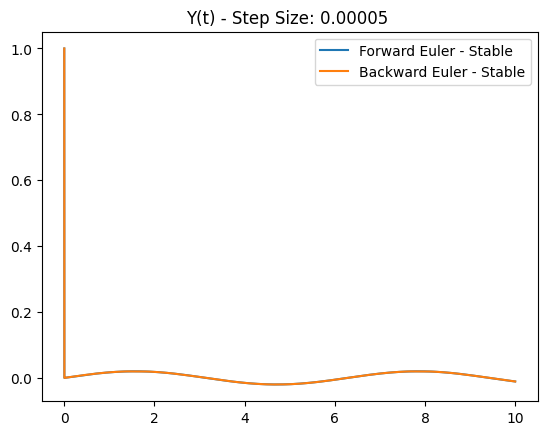

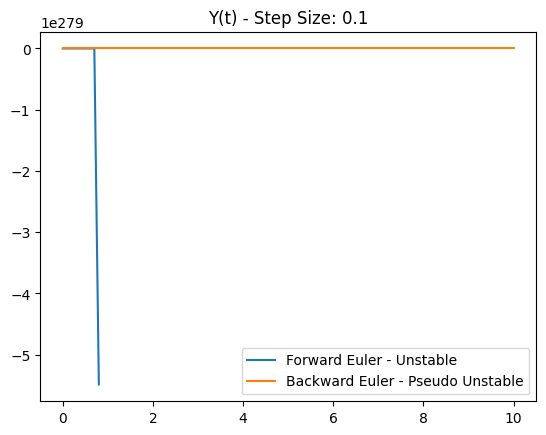

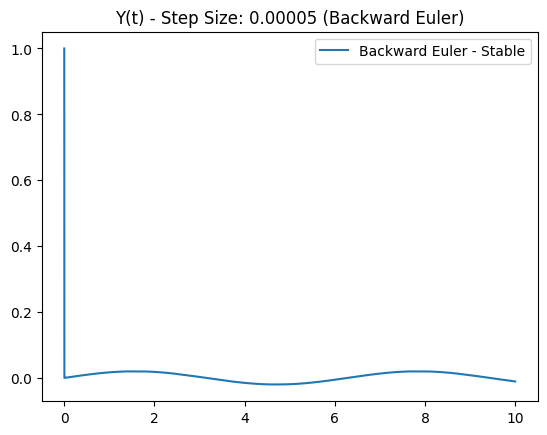

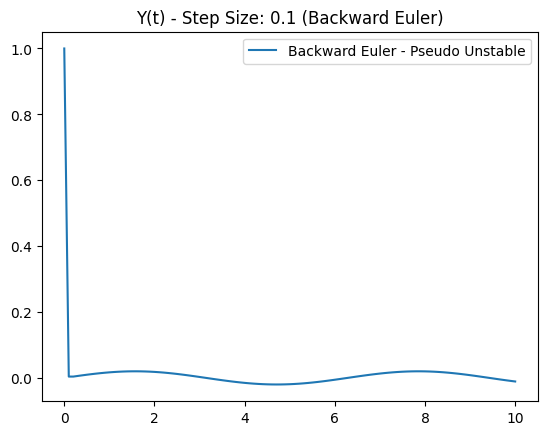

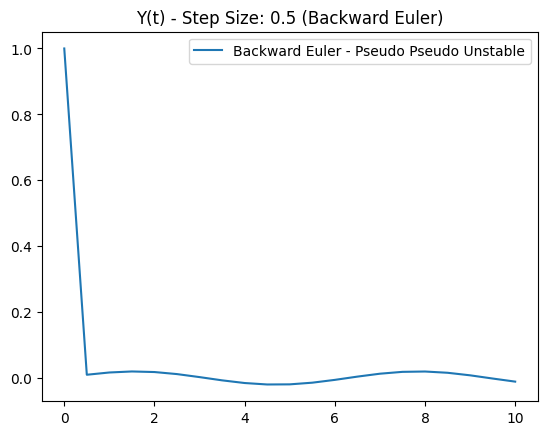

Stiffness ratio range: 4999.96000631922 to 5002.0
Stiffness ratio at steady state (y≈0): 5000.0


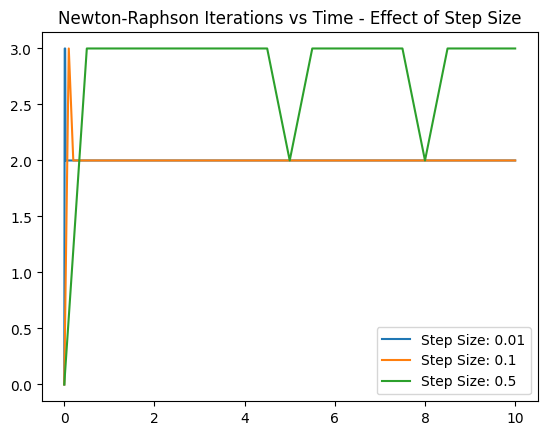

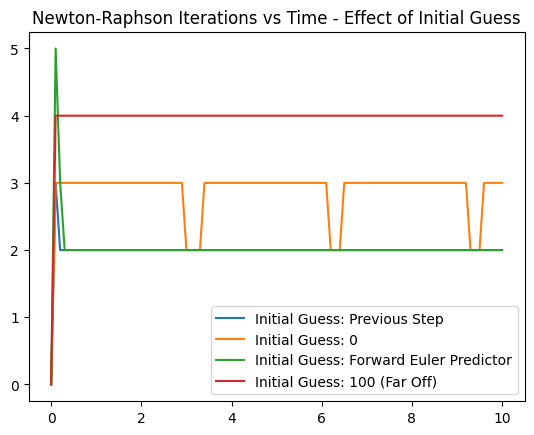

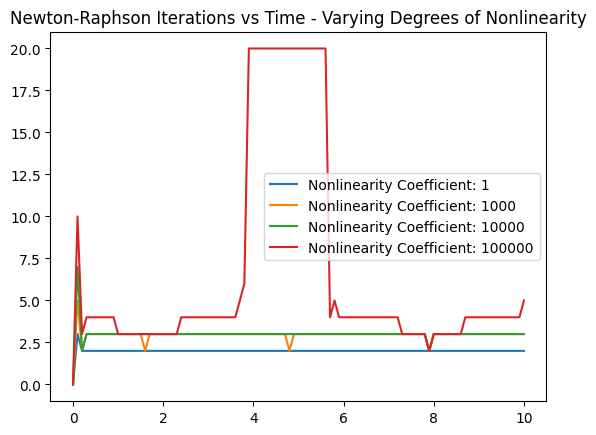

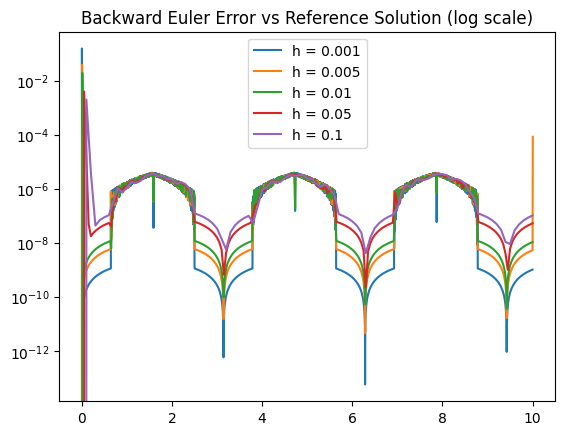

Physical Bounds Check:
Reference Solution Min y: -0.01999684039005925
Reference Solution Max y: 1.0
Reference Solution Max |y|: 1.0
Expected Steady-State Amplitude (~10/k): 0.02


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# PART 1 - OPTION D (Mechanical System with High Damping) - NONLINEAR
# dy/dx = (-k/c) * y - y^2 + (1/c)*(10*sin(x))     <-- the -y^2 makes it nonlinear in y

k = 500
c = 0.1

y_init = 1
y_prime = 0


def ForwardEuler(stepSizes, k,c,y_init):
    #Initialize Arrays That Will Be Returned
    submit_y_vals = []
    submit_x_vals = []

    for stepSize in stepSizes:
        #Initialize X Values
        x_vals = np.arange(0, 10+stepSize, stepSize)

        #Initial Conditions
        y_vals = np.array([y_init])

        # Forward Euler Integration Scheme
        for i in range(x_vals.shape[0]-1):
            y_vals = np.append(y_vals, y_vals[i] + stepSize * ((-k/c) * (y_vals[i]) - (y_vals[i])**2 + (1/c) * 10*np.sin(x_vals[i])))
        submit_y_vals.append(y_vals)
        submit_x_vals.append(x_vals)

    return np.array([submit_y_vals, submit_x_vals], dtype=object)

def NewtonRaphson(y_n, x_next, stepSize, k,c, alpha=1, initial_guess=None, tol=1e-6, max_iter=20):
    #Initial Guess (defaults to y_n, the previous step value)
    y = y_n if initial_guess is None else initial_guess

    #Iteration Counter
    iterations = 0

    for j in range(max_iter):
        iterations += 1
        #Residual g(y) = y - y_n - h * f(x_next, y)
        g = y - y_n - stepSize * ((-k/c) * y - alpha*y**2 + (1/c) * 10*np.sin(x_next))

        #Convergence Check
        if abs(g) < tol:
            return y, iterations

        #Derivative g'(y) = 1 - h * df/dy = 1 + h*(k/c) + 2*h*alpha*y
        g_prime = 1 - stepSize * (-k/c - 2*alpha*y)

        #Newton Step
        y = y - g/g_prime

    return y, iterations


def BackwardEuler(stepSizes, k,c,y_init, alpha=1, guess_strategy='previous'):
    #Initialize Arrays That Will Be Returned
    submit_y_vals = []
    submit_x_vals = []
    submit_iter_counts = []

    for stepSize in stepSizes:
        #Initialize X Values
        x_vals = np.arange(0, 10+stepSize, stepSize)

        #Initial Conditions
        y_vals = np.array([y_init])
        iter_counts = np.array([0])

        # Backward Euler Integration Scheme
        for i in range(x_vals.shape[0]-1):
            #Choose Initial Guess Based on Strategy
            if guess_strategy == 'previous':
                guess = y_vals[i]
            elif guess_strategy == 'zero':
                guess = 0.0
            elif guess_strategy == 'forward_euler':

                #This works by using forward euler as an initial guess that Newton-Raphson then refines if further
                #(Reference: https://math.stackexchange.com/questions/152159/how-to-correctly-apply-newton-raphson-method-to-backward-euler-method)

                guess = y_vals[i] + stepSize * ((-k/c)*y_vals[i] - alpha*y_vals[i]**2 + (1/c)*10*np.sin(x_vals[i]))

            elif guess_strategy == 'far_off':
                guess = 100.0
            else:
                guess = y_vals[i]
            y_next, iters = NewtonRaphson(y_vals[i], x_vals[i+1], stepSize, k,c, alpha, initial_guess=guess)
            y_vals = np.append(y_vals, y_next)
            iter_counts = np.append(iter_counts, iters)
        submit_y_vals.append(y_vals)
        submit_x_vals.append(x_vals)
        submit_iter_counts.append(iter_counts)

    return np.array([submit_y_vals, submit_x_vals, submit_iter_counts], dtype=object)


x_forward_stable = ForwardEuler([0.00005], k,c,y_init)
x_forward_unstable = ForwardEuler([0.1], k,c,y_init)

x_backward_stable = BackwardEuler([0.00005], k,c,y_init)
x_backward_pseudo_unstable = BackwardEuler([0.1], k,c,y_init)

x_backward_pseudo_pseudo_unstable = BackwardEuler([0.5], k,c,y_init) # This is just to show that the instability gets worse as step size increases (not required for submission, but I thought it would be interesting to include)


plt.plot(x_forward_stable[1][0], x_forward_stable[0][0], label='Forward Euler - Stable')
plt.plot(x_backward_stable[1][0], x_backward_stable[0][0], label='Backward Euler - Stable')
plt.title('Y(t) - Step Size: 0.00005 ')
plt.legend()
plt.show()

plt.plot(x_forward_unstable[1][0], x_forward_unstable[0][0], label='Forward Euler - Unstable')
plt.plot(x_backward_pseudo_unstable[1][0], x_backward_pseudo_unstable[0][0], label='Backward Euler - Pseudo Unstable')
plt.title('Y(t) - Step Size: 0.1')
plt.legend()
plt.show()

plt.plot(x_backward_stable[1][0], x_backward_stable[0][0], label='Backward Euler - Stable')
plt.title('Y(t) - Step Size: 0.00005 (Backward Euler)')
plt.legend()
plt.show()

plt.plot(x_backward_pseudo_unstable[1][0], x_backward_pseudo_unstable[0][0], label='Backward Euler - Pseudo Unstable')
plt.title('Y(t) - Step Size: 0.1 (Backward Euler)')
plt.legend()
plt.show()

plt.plot(x_backward_pseudo_pseudo_unstable[1][0], x_backward_pseudo_pseudo_unstable[0][0], label='Backward Euler - Pseudo Pseudo Unstable')
plt.title('Y(t) - Step Size: 0.5 (Backward Euler)')
plt.legend()
plt.show()


# Using the stable Backward Euler solution
x_ref = x_backward_stable[1][0]
y_ref = x_backward_stable[0][0]

# Fastest time scale: |df/dy| = |−k/c − 2y|
lambda_fast = np.abs(-k/c - 2*y_ref)

# Slowest time scale: forcing frequency = 1 rad/s
omega_slow = 1.0

# Stiffness ratio at each point
stiffness_ratio = lambda_fast / omega_slow

print("Stiffness ratio range: " + str(np.min(stiffness_ratio)) + " to " + str(np.max(stiffness_ratio)))
print("Stiffness ratio at steady state (y≈0): " + str(k/c))


# PART 1 - OPTION D - PART (c) CONVERGENCE BEHAVIOR
# Newton-Raphson iterations are stored in BackwardEuler's third return element (index [2])

# Convergence vs Step Size
conv_step_small = BackwardEuler([0.01], k,c,y_init)
conv_step_med = BackwardEuler([0.1], k,c,y_init)
conv_step_large = BackwardEuler([0.5], k,c,y_init)

plt.plot(conv_step_small[1][0], conv_step_small[2][0], label='Step Size: 0.01')
plt.plot(conv_step_med[1][0], conv_step_med[2][0], label='Step Size: 0.1')
plt.plot(conv_step_large[1][0], conv_step_large[2][0], label='Step Size: 0.5')
plt.title('Newton-Raphson Iterations vs Time - Effect of Step Size')
plt.legend()
plt.show()


# Convergence vs Initial Guess Quality
conv_guess_prev = BackwardEuler([0.1], k,c,y_init, guess_strategy='previous')
conv_guess_zero = BackwardEuler([0.1], k,c,y_init, guess_strategy='zero')
conv_guess_fe = BackwardEuler([0.1], k,c,y_init, guess_strategy='forward_euler')
conv_guess_far = BackwardEuler([0.1], k,c,y_init, guess_strategy='far_off')

plt.plot(conv_guess_prev[1][0], conv_guess_prev[2][0], label='Initial Guess: Previous Step')
plt.plot(conv_guess_zero[1][0], conv_guess_zero[2][0], label='Initial Guess: 0')
plt.plot(conv_guess_fe[1][0], conv_guess_fe[2][0], label='Initial Guess: Forward Euler Predictor')
plt.plot(conv_guess_far[1][0], conv_guess_far[2][0], label='Initial Guess: 100 (Far Off)')
plt.title('Newton-Raphson Iterations vs Time - Effect of Initial Guess')
plt.legend()
plt.show()


# Convergence vs System Nonlinearity (varying coefficient on y^2)
conv_nl_low = BackwardEuler([0.1], k,c,y_init, alpha=1)
conv_nl_med = BackwardEuler([0.1], k,c,y_init, alpha=1000)
conv_nl_high = BackwardEuler([0.1], k,c,y_init, alpha=10000)
conv_nl_extreme = BackwardEuler([0.1], k,c,y_init, alpha=100000)

plt.plot(conv_nl_low[1][0], conv_nl_low[2][0], label='Nonlinearity Coefficient: 1')
plt.plot(conv_nl_med[1][0], conv_nl_med[2][0], label='Nonlinearity Coefficient: 1000')
plt.plot(conv_nl_high[1][0], conv_nl_high[2][0], label='Nonlinearity Coefficient: 10000')
plt.plot(conv_nl_extreme[1][0], conv_nl_extreme[2][0], label='Nonlinearity Coefficient: 100000')
plt.title('Newton-Raphson Iterations vs Time - Varying Degrees of Nonlinearity')
plt.legend()
plt.show()


# PART 1 - OPTION D - PART (d) SOLUTION QUALITY
# Reference solution is the very fine-step Backward Euler computed above (h=0.00005)

ref_x = np.array(x_backward_stable[1][0], dtype=float)
ref_y = np.array(x_backward_stable[0][0], dtype=float)


# Error Analysis: Compare Various Step Sizes Against Reference
test_step_sizes = [0.001, 0.005, 0.01, 0.05, 0.1]

for h in test_step_sizes:
    sol = BackwardEuler([h], k,c,y_init)
    test_x = np.array(sol[1][0], dtype=float)
    test_y = np.array(sol[0][0], dtype=float)
    #Interpolate Reference Solution Onto Test Grid
    ref_interp = np.interp(test_x, ref_x, ref_y)
    err = np.abs(test_y - ref_interp)
    plt.plot(test_x, err, label='h = ' + str(h))
plt.title('Backward Euler Error vs Reference Solution (log scale)')
plt.yscale('log')
plt.legend()
plt.show()


# Physical Bounds Check
# For a damped forced system, |y_steady| should be bounded by ~|F0/k| during steady state
print("Physical Bounds Check:")
print("Reference Solution Min y: " + str(np.min(ref_y)))
print("Reference Solution Max y: " + str(np.max(ref_y)))
print("Reference Solution Max |y|: " + str(np.max(np.abs(ref_y))))


# For (-k/c)*y + (10/c)*sin(t) = 0 {y^2 is considered to be negligible because y is so small at steady state}
# We get y = (10/k) * sin(t) 
# So steady state amplitude should be ~0.2, technically slightly less due to the y^2 term not necessarily being negligible. 
print("Expected Steady-State Amplitude (~10/k): " + str(10/k))





# CITATIONS (Part 2)
# AI 
# I used Claude Opus 4.7 to answer this prompt
# "Please create the plots for the Newton-Raphson Convergence Behavior and the Bakcward Euler Error (w.r.t step size) analyses"
# It produced the code for those plots as you can see above.
# The reason I wanted it to do this is because I didn't want to go through and make the plots look good (It didn't seem interesting to me lol)



# (Normal) Sources Used:
# https://www.w3schools.com/python/matplotlib_intro.asp
# https://math.stackexchange.com/questions/152159/how-to-correctly-apply-newton-raphson-method-to-backward-euler-method




# Part Two - Option D (Damped Mechanical Oscillator)

## Intro & Model Selection
My real world system is analyzing how an extremely stiff vehicle suspension responds to compression/expansion and progresses through time.

The governing second order equation is:

$$\frac{dy}{dt} = -\frac{k}{c}y - y^2 + \frac{10}{c}\sin(t), \qquad y(0)=1$$

So,

$$\frac{dx}{dt} = -\frac{k}{c}x + \frac{10}{c}\sin(t)$$

With $k=500$ and $c=0.1$:

$$\frac{dx}{dt} = -5000\,x + 100\,\sin(t)$$

Initial condition:

$$x(0)=1$$



## Background of what each parameter means

-  **$x(t)$** — displacement from equilibrium (m). Positive = compression, negative = extension.
-  **$t$** — time (s).

-  **$k$** — spring stiffness (N/m). Sets how strongly the spring pulls the system back toward equilibrium

-  **$c$** — viscous damping coefficient (N·s/m). Sets how strongly motion is resisted by damping

-  **$\frac{k}{c}$** — relaxation/decay rate (s$^{-1}$). Controls how quickly $x(t)$ is driven back toward 0 in the absence of forcing. 

-  **$F(t)=10\sin(t)$** — external forcing (N). Represents a time-varying input (e.g., simplified road/actuator force) with

-  **$x(0)=1$** — initial displacement (m), meaning the system starts 1 m away from equilibrium at $t=0$.

-   **$-y^2$** — **nonlinear** restoring/dissipative term (I kind of just added this to make things harder for myself lol). 


*NOTE* I added the "-y^2" term to make the differential equation non-linear so that it makes sense to use Newton-Raphson w/ Backward Euler, otherwise Newton-Raphson will just converge in 1 iteration (because the differeantial equation is linear, we can just solve for the k+1 timestep state in terms of the k time step state). 

## Explanation for Nonlinear Term & System Importance

We can consider the nonlinear term in this equation to represent a part of the suspension system that activates when the suspension system is under a large load. For example, if you have a a cushion at the top of your suspension spring that exists so that if the spring were to ever undergo a large amount of compression, then there's an extra layer of cuhsioning before the spring directly contacts the hull of the car. Therefore, this differential equation more accurately represents the system, as compared to an idealized Hooke's Law. Obviously, this sstem is relevant for engineers to study, becasue creating efficient and performant suspension systems is of significant benefit to humanity.

## Demonstration of Stiffness

As you can see if we use Forward Euler on this system with a relatively small step size (of 0.1), we can see behavior that indicates Forward Euler isn't accurately modeling the system's dynamics. In the plot, we can see Forward Euler extremely sharply decrease to an extremely low value, while Backward Euler stays much more stable and accurate. Furthermore, as you can see the ratio of the fastest to slowest time scales is ~5000 for each time step (with the range being from ~4999 to 5000). This means some dynamics happen 5000 times faster than other dynamics in the system, which is a hallmark of stiff differential equations. By the way, the reason why there are different ratios for each time step is due to the non-linear term in the differential equation.

### A Note on The Impracticality of Explicit Methods for Stiff Differential Equations

Now that we are able to see that our system is stiff, it's important to note that explicit methods like Forward Euler are impractical to model these systems. Assuming purely linear dynamics, Forward Euler would require a step size of ~0.00005. Imagine if you wanted to know what the system was doing after 5 seconds. You would need to compute 100,000 time steps to be able to calculate your state at 5 seconds. Now consider an implict method like Backward Euler, you can increase your step size to ~0.1 and arrive at the state after just 50 time steps. Clearly one solution is an order of magnitude swifter than the other.

## Analytical Solution for the Backward Euler Implicit Equation

Starting from the Backward Euler scheme:

$$y_{n+1} = y_n + h\left(-\frac{k}{c}y_{n+1} - y_{n+1}^2 + \frac{10}{c}\sin(t_{n+1})\right)$$

Rearranging all terms to one side:

$$h\,y_{n+1}^2 + \left(1 + \frac{hk}{c}\right)y_{n+1} - \left(y_n + \frac{10h}{c}\sin(t_{n+1})\right) = 0$$

This is a standard quadratic $ay^2 + by + c_0 = 0$ with:

$$a = h, \quad b = 1 + \frac{hk}{c}, \quad c_0 = -\left(y_n + \frac{10h}{c}\sin(t_{n+1})\right)$$

Solved via the quadratic formula:

$$y_{n+1} = \frac{-b \pm \sqrt{b^2 - 4ac_0}}{2a}$$

We select the root closer to $y_n$ (typically the "$-$" branch since $b > 0$).

Although this particular nonlinearity ($-y^2$) yields a closed-form quadratic, Newton-Raphson is used here because most nonlinear implicit equations (cubics, transcendentals, coupled systems) cannot be solved analytically.

**NOTE:** I used Claude Opus 4.6 to format this proof, because I'm not great at Markdown Math Notation


## Update Step For Newton-Raphson

Newton-Raphson iteratively solves the implicit Backward Euler residual $g(y) = 0$:

$$g(y) = y - y_n - h\left(-\frac{k}{c}y - y^2 + \frac{10}{c}\sin(t_{n+1})\right)$$

The Jacobian (derivative of the residual with respect to $y$):

$$g'(y) = 1 + \frac{hk}{c} + 2hy$$

The Newton-Raphson update formula:

$$y^{(j+1)} = y^{(j)} - \frac{g(y^{(j)})}{g'(y^{(j)})}$$

Starting from initial guess $y^{(0)} = y_n$, iterate until $|g(y^{(j)})| < \text{tol}$.

**NOTE:** I used Claude Opus 4.6 to format this proof, because I'm not great at Markdown Math Notation


## Results & Analysis

When looking at the plots above when I say "Pseudo Unstable" I mean that I used a step size for Backward Euler that would make Forward Euler diverge (not that the Backward Euler solution is diverging). As you can tell, even for larger step sizes Backward Euler w/ Newton Raphson solver is showing how it handles the fast transient decay, and also tracks the long term cyclic growth modeled by the sine wave. To see this, look how at the beginning Backwards Euler tracks the sharp decline well, and then immediately shifts to behaving like a sine-wave. That shows we are able to handle the true stiff nature of this ODE. As you can see from the plots, having smaller step sizes improves the convergence speed of the Newton-Raphson solver. Also, the quality of the initial guess matters. A good starting point would be to ue the previous state as your intitial guess for the Newton-Raphson solver, implying you took a small enough time step that your **t+1** state is nearby to your **t** state. However, after researching online, I found out that using the Forward Euler method to find your t+1 state, and then feed that into the Newton-Raphson solver as an initial guess leads to more quicker convergence. Furthermore, smaller non-linearity on your ODE results in the Newton-Raphson solver taking fewer and fewer iterations to converge. Lastly, having a smaller step size results in the errors of the Backward Euler method being smaller.

## Performance Analysis

The main thing to consider here is how many total operations each method needs to get a solution out to $t = 10$. Forward Euler is cheap per step (just one function evaluation), but because it needs $h < 0.0004$ to not blow up, you end up needing around 200,000 steps. Backward Euler costs more per step because you have to run Newton-Raphson, but you can take way bigger steps.

When considering performance, you can consdier the number of operations each method takes. Forward Euler is an extremely "cheap" integration scheme, where it does one evaluation every time step. However, in the case of stiff ODEs, for it to remain numerically stable you are forced to have a timestep on the order of 0.0005. To get to t=10, you have to iterate roughly 200,000 times. Backward Euler, on the contrary is more expensive per time step, however, you can take orders of magnitude fewer time steps.

| | **Forward Euler** ($h = 0.00005$) | **Backward Euler** ($h = 0.01$) | **Backward Euler** ($h = 0.1$) |
|---|---|---|---|
| Steps to $t = 10$ | 200,000 | 1,000 | 100 |
| NR iters per step | 0 | ~2-3 | ~2-3 |
| Total function evals | ~200,000 | ~2,000-3,000 | ~200-300 |
| Stability | Barely stable | Very stable | Very stable |
| Accuracy vs reference | Is the reference | Very close | Slight smoothing |

So even though Backward Euler does ~3x more work per step (computing $g$, $g'$, and the Newton update), the fact that it can take steps that are 2,000x larger completely dominates the comparison. Backward Euler at $h = 0.1$ does roughly 200-300 total function evaluations compared to Forward Euler's 200,000. That's about a 1000x reduction in total compute, which makes Backward Euler on the compute front.

With respect to accuracy, it is true that if you pick a sufficiently small step size for Forward Euler, you can get more accurate results than Backward Euler. However you would need to perform orders of magnitude more computations for that slight edge. In fact, you would be far better off slightly lowering the step size of Bakcward Euler instead, where you are getting increased accuraacy while not compromising on the efficiency front.

My practical recommendation would be: if you're working with a stiff system like this one (stiffness ratio ~5000), just use Backward Euler with Newton-Raphson and pick your step size based on accuracy, not stability. That's the whole point of implicit methods. If you want to squeeze more performance out, the adaptive step size controller is the way to go, because it automatically takes tiny steps during the initial transient and big steps during the steady-state sine wave tracking.


In general, if you are working with complex and stiff dynamics, it's illogical to use Forward Euler. You are just spending too much compute when you don't need to. Instead you should use methods like Backward Euler that are structurally more robust integration schemes. Granted, Backward Euler is an implicit method, so you need Newton-Raphson to handle non-linear dynamics, but that's still a significatnly beneficial option, rather than accepting incredibly small time-steps Forward Euler forces you to use. Furthermore, there do exist systems where it may make even more sense to use different integration schemes like Symplectic or Vartiational integrators. These are used when you know your system conserves energy, and therefore these integration schemes will use this fact to ensure the energy doesn't asymptotically grow thereby increasing stability to an extent that, in some cases beats Backward Euler or even RK4.


## Conclusion
Overall, I learned that it's important to consider your system dyanmics when designing integrators for them. I also learned about the tradeoff between computational complexity and accuracy. Furthermore, there's no real one integrator that's the "best". It's all tradeoffs, for example, Forward Euler could be the best solution if you have extremely stable linear dynamics. This is becuase it is extremely simple computationally, and it will have pretty good efficiency/accuracy. However, for other cases (like Stiff ODEs) Implicit Methods (like Backwards Euler) may be better suited to handle the task. Some challenges I faced were figuring out the how to incorporate Forward Euler "Guesses" into the Newton-Raphson method of Backward Euler toimprove convergence speed. Another challenge was dealing with the non-linear nature of the ODE. I know I made it harder for myself, but I'm pleased with how much more I was able to learn because of it. 













Part 3.1 Newton-Raphson comparison
h = 5.0, x_next = 0.1, initial guess = -2499.6
Undamped: converged = False, iterations = 8
Damped: converged = True, iterations = 5, total backtracks = 11
Final alpha = 1.0, damping needed = True
Backtracks per NR iteration:
[11  0  0  0  0]
Alpha per NR iteration:
[4.8828125e-04 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00]


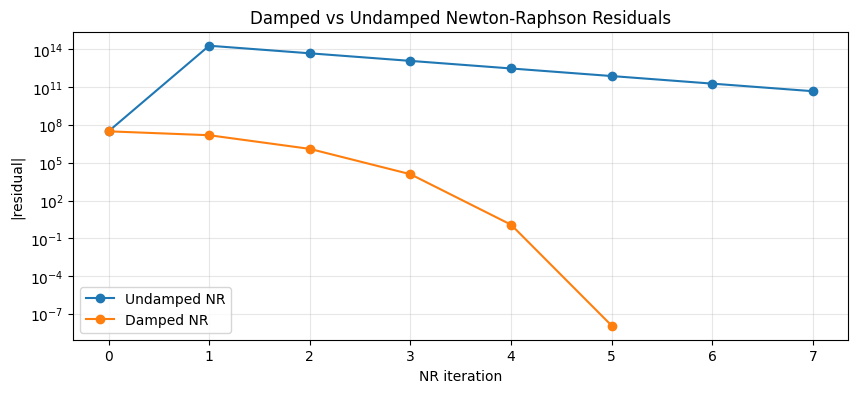

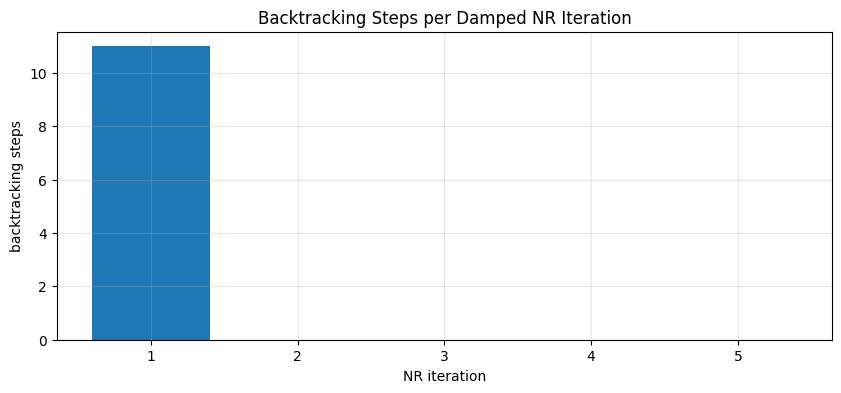

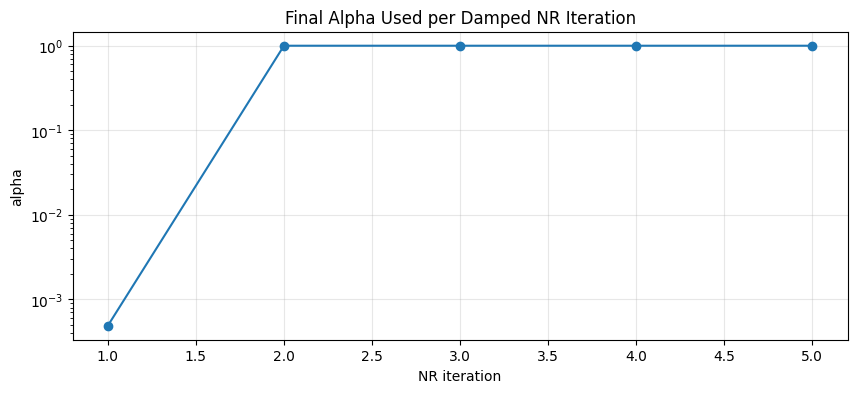


Part 3.2 Adaptive Backward Euler report
tol = 0.0001, h0 = 2.0, h_min = 1e-06, h_max = 2.0
accepted = 5, rejected = 0, NR failures = 0
total NR iterations = 30
total backtracks = 0, steps needing damping = 0


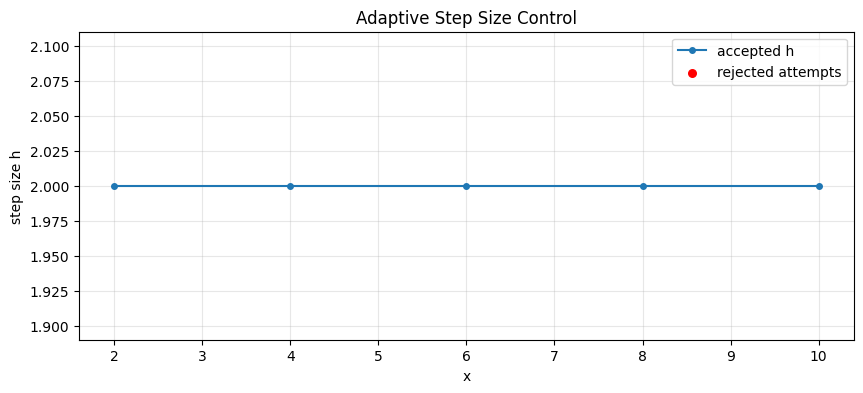

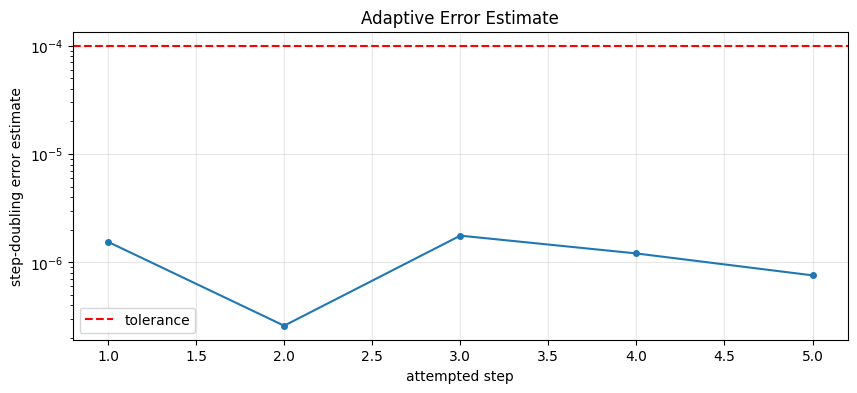

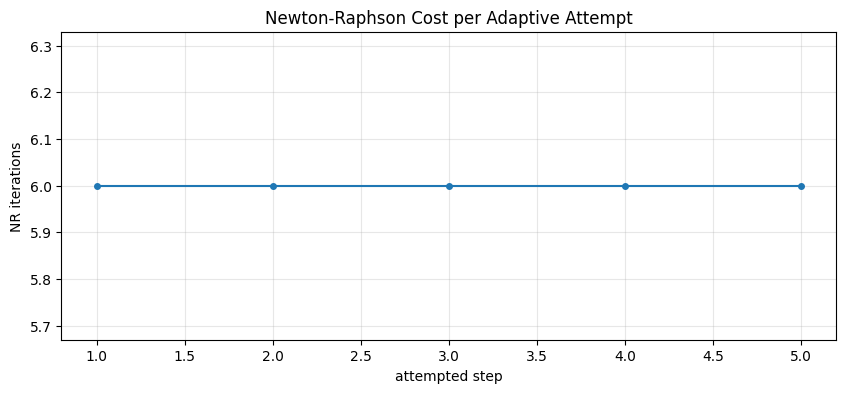

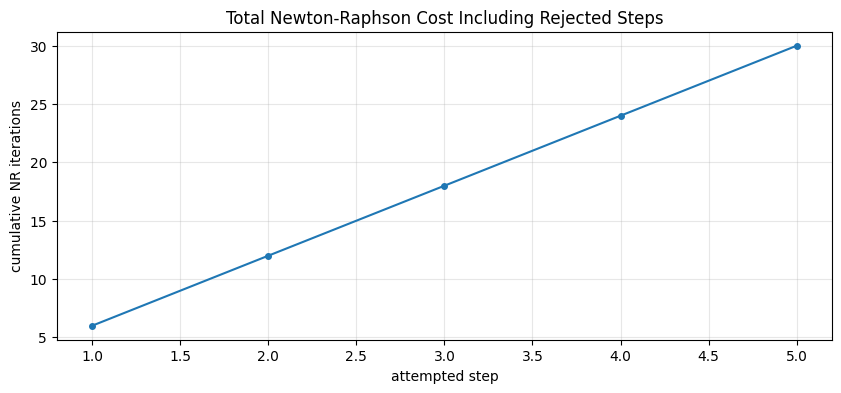

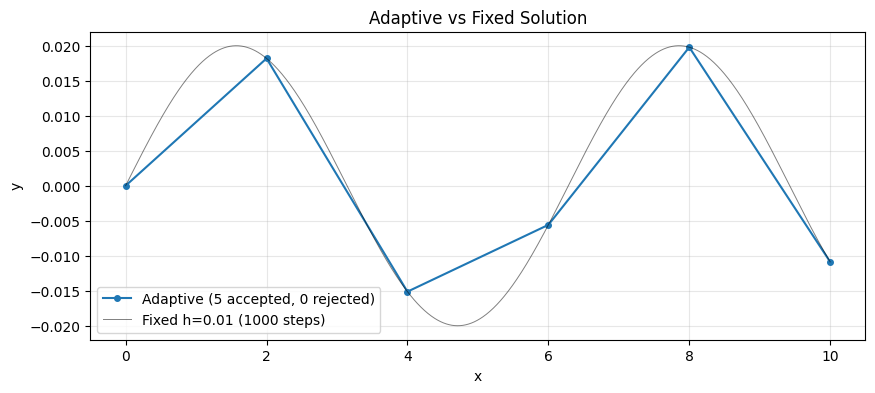


Part 3.3 Large initial step size test
tol = 0.0001, h0 = 20
accepted = 5, rejected = 0, NR failures = 0
total NR iterations = 30
total backtracks = 0, steps needing damping = 0


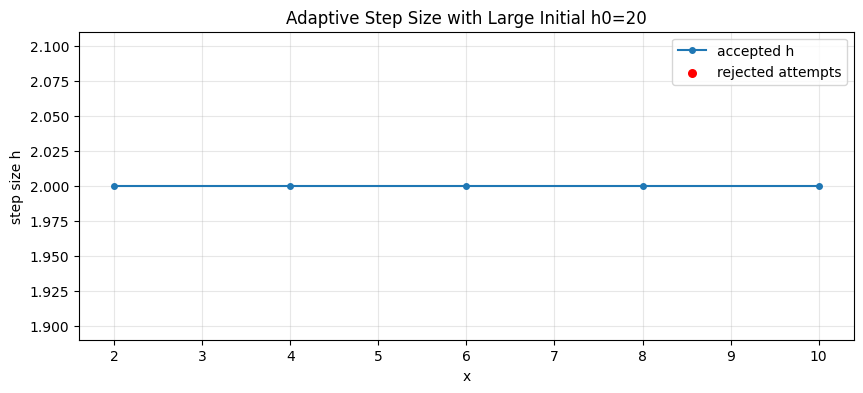


Part 3.4 Tight tolerance test
tol = 1e-08, h0 = 2.0
accepted = 749, rejected = 30, NR failures = 0
total NR iterations = 2340
total backtracks = 0, steps needing damping = 0


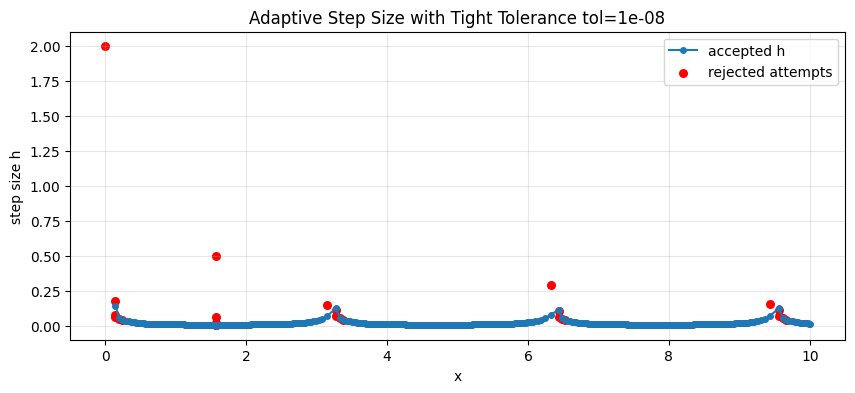

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def DampedNewtonRaphson(y_n, x_next, stepSize, k,c, tol=1e-6, max_iter=20, alpha_min=1e-4, y0=None, damping=True):
    y = y_n if y0 is None else y0
    iters = 0
    total_backtracks = 0
    damping_used = False
    final_alpha = 1.0
    converged = False
    line_search_failed = False

    residual_history = []
    alpha_history = []
    backtrack_history = []

    for j in range(max_iter):
        g = y - y_n - stepSize * ((-k/c) * y - y**2 + (1/c) * 10*np.sin(x_next))
        residual_history.append(abs(g))

        if abs(g) < tol:
            converged = True
            break

        g_prime = 1 - stepSize * (-k/c - 2*y)
        if abs(g_prime) < 1e-15:
            break

        delta = -g/g_prime

        alpha = 1.0
        backtracks = 0

        if damping:
            while True:
                y_trial = y + alpha*delta
                g_trial = y_trial - y_n - stepSize * ((-k/c) * y_trial - y_trial**2 + (1/c) * 10*np.sin(x_next))

                if abs(g_trial) < abs(g):
                    break

                if alpha <= alpha_min:
                    line_search_failed = True
                    break

                alpha = max(alpha/2, alpha_min)
                backtracks += 1

            if line_search_failed:
                final_alpha = alpha
                alpha_history.append(alpha)
                backtrack_history.append(backtracks)
                break

        if backtracks > 0:
            damping_used = True

        total_backtracks += backtracks
        final_alpha = alpha

        alpha_history.append(alpha)
        backtrack_history.append(backtracks)

        y = y + alpha*delta
        iters += 1

        g_new = y - y_n - stepSize * ((-k/c) * y - y**2 + (1/c) * 10*np.sin(x_next))
        if abs(g_new) < tol:
            residual_history.append(abs(g_new))
            converged = True
            break

    info = {
        "residuals": np.array(residual_history),
        "alphas": np.array(alpha_history),
        "backtracks": np.array(backtrack_history),
        "line_search_failed": line_search_failed
    }

    return y, iters, total_backtracks, final_alpha, damping_used, converged, info


def AdaptiveBackwardEuler(h0, tol, k,c, y_init, x_end=10.0, h_min=1e-6, h_max=1.0, safety=0.9):
    x_vals = [0.0]
    y_vals = [y_init]
    h_history = []

    h_attempts = []
    x_attempts = []
    err_history = []
    accepted_flags = []
    iter_history = []
    backtrack_step_history = []

    accepted = 0
    rejected = 0
    nr_failures = 0
    total_iters = 0
    total_backtracks = 0
    damped_steps = 0

    h = h0
    while x_vals[-1] < x_end:
        h = max(h_min, min(h_max, h))

        if x_vals[-1] + h > x_end:
            h = x_end - x_vals[-1]

        x_n = x_vals[-1]
        y_n = y_vals[-1]

        y_h, n1, b1, _, d1, c1, _ = DampedNewtonRaphson(y_n, x_n + h, h, k,c)
        y_half, n2, b2, _, d2, c2, _ = DampedNewtonRaphson(y_n, x_n + h/2, h/2, k,c)
        y_h2, n3, b3, _, d3, c3, _ = DampedNewtonRaphson(y_half, x_n + h, h/2, k,c)

        step_iters = n1 + n2 + n3
        step_backtracks = b1 + b2 + b3

        total_iters += step_iters
        total_backtracks += step_backtracks

        if d1 or d2 or d3:
            damped_steps += 1

        h_attempts.append(h)
        x_attempts.append(x_n)
        iter_history.append(step_iters)
        backtrack_step_history.append(step_backtracks)

        if not (c1 and c2 and c3):
            nr_failures += 1
            rejected += 1
            err_history.append(np.nan)
            accepted_flags.append(False)

            h = max(h_min, h/4)

            if h <= h_min:
                break

            continue

        err = abs(y_h2 - y_h)
        err_history.append(err)

        eps = 1e-14
        h_new = h * np.sqrt(tol / (err + eps))
        h_new = max(h_min, min(h_max, safety * h_new))

        if err <= tol:
            x_vals.append(x_n + h)
            y_vals.append(y_h2)
            h_history.append(h)

            accepted += 1
            accepted_flags.append(True)

            h = h_new
        else:
            rejected += 1
            accepted_flags.append(False)

            h = h_new

            if h <= h_min:
                break

    stats = {
        "accepted": accepted,
        "rejected": rejected,
        "nr_failures": nr_failures,
        "total_iters": total_iters,
        "total_backtracks": total_backtracks,
        "damped_steps": damped_steps,
        "h_attempts": np.array(h_attempts),
        "x_attempts": np.array(x_attempts),
        "err_history": np.array(err_history),
        "accepted_flags": np.array(accepted_flags),
        "iter_history": np.array(iter_history),
        "backtrack_step_history": np.array(backtrack_step_history)
    }

    return np.array(x_vals), np.array(y_vals), np.array(h_history), stats


def BackwardEulerFixed(h, k,c,y_init):
    x_vals = np.arange(0, 10+h, h)
    y_vals = np.array([y_init])
    iter_counts = []

    for i in range(x_vals.shape[0]-1):
        y_next, n, _, _, _, _, _ = DampedNewtonRaphson(y_vals[i], x_vals[i+1], h, k,c)
        y_vals = np.append(y_vals, y_next)
        iter_counts.append(n)

    return x_vals, y_vals, np.array(iter_counts)


h_test = 5.0
x_test = 0.1
y_n_test = 0.0
nr_demo_max_iter = 8

y_vertex = -((1 + h_test*k/c)/(2*h_test))
y0_bad = y_vertex + 0.5

y_u, n_u, b_u, a_u, d_u, c_u, info_u = DampedNewtonRaphson(
    y_n_test, x_test, h_test, k,c,
    max_iter=nr_demo_max_iter, y0=y0_bad, damping=False
)

y_d, n_d, b_d, a_d, d_d, c_d, info_d = DampedNewtonRaphson(
    y_n_test, x_test, h_test, k,c,
    max_iter=nr_demo_max_iter, y0=y0_bad, damping=True
)

print("Part 3.1 Newton-Raphson comparison")
print("h = " + str(h_test) + ", x_next = " + str(x_test) + ", initial guess = " + str(y0_bad))
print("Undamped: converged = " + str(c_u) + ", iterations = " + str(n_u))
print("Damped: converged = " + str(c_d) + ", iterations = " + str(n_d) + ", total backtracks = " + str(b_d))
print("Final alpha = " + str(a_d) + ", damping needed = " + str(d_d))
print("Backtracks per NR iteration:")
print(info_d["backtracks"])
print("Alpha per NR iteration:")
print(info_d["alphas"])

plt.figure(figsize=(10,4))
plt.semilogy(info_u["residuals"], "o-", label="Undamped NR")
plt.semilogy(info_d["residuals"], "o-", label="Damped NR")
plt.xlabel("NR iteration")
plt.ylabel("|residual|")
plt.title("Damped vs Undamped Newton-Raphson Residuals")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.bar(np.arange(1, len(info_d["backtracks"])+1), info_d["backtracks"])
plt.xlabel("NR iteration")
plt.ylabel("backtracking steps")
plt.title("Backtracking Steps per Damped NR Iteration")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(np.arange(1, len(info_d["alphas"])+1), info_d["alphas"], "o-")
plt.yscale("log")
plt.xlabel("NR iteration")
plt.ylabel("alpha")
plt.title("Final Alpha Used per Damped NR Iteration")
plt.grid(True, alpha=0.3)
plt.show()


tol_target = 1e-4
h0_start = 2.0
h_min_val = 1e-6
h_max_val = 2.0

x_a, y_a, h_hist, stats = AdaptiveBackwardEuler(
    h0=h0_start, tol=tol_target, k=k, c=c, y_init=0,
    h_min=h_min_val, h_max=h_max_val
)

print("")
print("Part 3.2 Adaptive Backward Euler report")
print("tol = " + str(tol_target) + ", h0 = " + str(h0_start) + ", h_min = " + str(h_min_val) + ", h_max = " + str(h_max_val))
print("accepted = " + str(stats["accepted"]) + ", rejected = " + str(stats["rejected"]) + ", NR failures = " + str(stats["nr_failures"]))
print("total NR iterations = " + str(stats["total_iters"]))
print("total backtracks = " + str(stats["total_backtracks"]) + ", steps needing damping = " + str(stats["damped_steps"]))

accepted_mask = stats["accepted_flags"]

plt.figure(figsize=(10,4))
plt.plot(x_a[1:], h_hist, "o-", markersize=4, label="accepted h")
plt.scatter(stats["x_attempts"][~accepted_mask], stats["h_attempts"][~accepted_mask],
            color="red", s=30, label="rejected attempts")
plt.xlabel("x")
plt.ylabel("step size h")
plt.title("Adaptive Step Size Control")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
good_err = np.isfinite(stats["err_history"])
plt.semilogy(np.arange(1, len(stats["err_history"])+1)[good_err],
             stats["err_history"][good_err], "o-", markersize=4)
plt.axhline(tol_target, color="red", linestyle="--", label="tolerance")
plt.xlabel("attempted step")
plt.ylabel("step-doubling error estimate")
plt.title("Adaptive Error Estimate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(np.arange(1, len(stats["iter_history"])+1), stats["iter_history"], "o-", markersize=4)
plt.xlabel("attempted step")
plt.ylabel("NR iterations")
plt.title("Newton-Raphson Cost per Adaptive Attempt")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(np.arange(1, len(stats["iter_history"])+1), np.cumsum(stats["iter_history"]), "o-", markersize=4)
plt.xlabel("attempted step")
plt.ylabel("cumulative NR iterations")
plt.title("Total Newton-Raphson Cost Including Rejected Steps")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(x_a, y_a, "o-", markersize=4, label="Adaptive (" + str(stats["accepted"]) + " accepted, " + str(stats["rejected"]) + " rejected)")
xf, yf, _ = BackwardEulerFixed(0.01, k,c,0)
plt.plot(xf, yf, "k-", linewidth=0.7, alpha=0.5, label="Fixed h=0.01 (" + str(len(xf)-1) + " steps)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Adaptive vs Fixed Solution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


h0_large = 20

x_l, y_l, h_hist_l, stats_l = AdaptiveBackwardEuler(
    h0=h0_large, tol=tol_target, k=k, c=c, y_init=0,
    h_min=h_min_val, h_max=h_max_val
)

print("")
print("Part 3.3 Large initial step size test")
print("tol = " + str(tol_target) + ", h0 = " + str(h0_large))
print("accepted = " + str(stats_l["accepted"]) + ", rejected = " + str(stats_l["rejected"]) + ", NR failures = " + str(stats_l["nr_failures"]))
print("total NR iterations = " + str(stats_l["total_iters"]))
print("total backtracks = " + str(stats_l["total_backtracks"]) + ", steps needing damping = " + str(stats_l["damped_steps"]))

accepted_mask_l = stats_l["accepted_flags"]

plt.figure(figsize=(10,4))
plt.plot(x_l[1:], h_hist_l, "o-", markersize=4, label="accepted h")
plt.scatter(stats_l["x_attempts"][~accepted_mask_l], stats_l["h_attempts"][~accepted_mask_l],
            color="red", s=30, label="rejected attempts")
plt.xlabel("x")
plt.ylabel("step size h")
plt.title("Adaptive Step Size with Large Initial h0=" + str(h0_large))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


tol_tight = 1e-8

x_t, y_t, h_hist_t, stats_t = AdaptiveBackwardEuler(
    h0=h0_start, tol=tol_tight, k=k, c=c, y_init=0,
    h_min=h_min_val, h_max=h_max_val
)

print("")
print("Part 3.4 Tight tolerance test")
print("tol = " + str(tol_tight) + ", h0 = " + str(h0_start))
print("accepted = " + str(stats_t["accepted"]) + ", rejected = " + str(stats_t["rejected"]) + ", NR failures = " + str(stats_t["nr_failures"]))
print("total NR iterations = " + str(stats_t["total_iters"]))
print("total backtracks = " + str(stats_t["total_backtracks"]) + ", steps needing damping = " + str(stats_t["damped_steps"]))

accepted_mask_t = stats_t["accepted_flags"]

plt.figure(figsize=(10,4))
plt.plot(x_t[1:], h_hist_t, "o-", markersize=4, label="accepted h")
plt.scatter(stats_t["x_attempts"][~accepted_mask_t], stats_t["h_attempts"][~accepted_mask_t],
            color="red", s=30, label="rejected attempts")
plt.xlabel("x")
plt.ylabel("step size h")
plt.title("Adaptive Step Size with Tight Tolerance tol=" + str(tol_tight))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Part Three

## Review of Part 2

My real world system is analyzing how an extremely stiff vehicle suspension responds to compression/expansion and progresses through time.

The governing second order equation is:

$$\frac{dy}{dt} = -\frac{k}{c}y - y^2 + \frac{10}{c}\sin(t), \qquad y(0)=1$$

So,

$$\frac{dx}{dt} = -\frac{k}{c}x + \frac{10}{c}\sin(t)$$

With $k=500$ and $c=0.1$:

$$\frac{dx}{dt} = -5000\,x + 100\,\sin(t)$$

Initial condition:

$$x(0)=1$$


Please reference Part 2 for more details about what each parameter means.


The stiffness parameter would be $k/c$ so roughly $5000$ (neglecting the effect of the non-linear term). This means that one aspect of the system dynamics resolve ~5000 times faster than the other part, effectively spliiting the trajectory into short-term and long-term segments. Where, in the short term only one aspect of the system dynamics are relevant (overpowering the other elements of the dynamics), and same for the long-term.


## Newton-Raphson Damping Implementation

In the basic Newton-Raphson method, each iteration updates the solution using the full Newton step (y_new = y + (-g/g_prime)).
This functionally works well if the initial guess is somewhere close to the root of the function. However, if the initial guess is far away, or the step size is too large performing a full newton step, might cause infinite oscillations or other unstable behavior. In some cases, it may even cause the residual to increase and diverge to infinity instead of converging to zero.

The Damped Newton Raphson Method mitigates this by applying another factor to (-g/g_prime). For the purposes of the explanation I'll reference this factor as "alpha". The idea is that initially we set alpha to be 1, resulting in y_new = y + alpha*(-g/g_prime). Then if after this step the residual didn't decrease, we cut alpha in half (so in this alpha would become 0.5) and then try to do the Newton step again and keep repeating until the residual does start to decrease or a minimum threshold is met. The hope is that through this process we can find the "right" step size to make progress on reducing the residual.

Some interesting properties of this approach are that it is always strictly better than the Undamped Newton Raphson Method, because it initially attempts to do the naive full Newton step, but then intelligently "adjusts" the step size until it actaully makes progress.

A more concrete example where Newton Raphson with Damping is helpful (in addition to the system dynamics themsleves) is when we want to use a large step size, for example a step size of 5.0, and an initial condition where a full Newton step would be too aggressive. As you can see in the plots above, the Undamped version of Newton-Raphson fails to reduce the residual to near zero for 7+ iterations, whilst the Damped version managed to get the residual close to zero within just 4-5 iterations. Furthermore, computationally from the plots you can see the alpha backtracking was only necessary for the very first iteration, after which point the state was in a location in phase space that was stable enough for us to take full Newton steps.


## Adaptive Step Size Implementation

Step doubling estimates the local error by solving the same interval in two different ways. 

Firstly, the method takes a full Newton step of size "h." Then it solves the same interval using two smaller half steps of size h/2. Taking two half steps is more accurate because it means we are able to take more samples of the function, better approximating the continuous nature of the solution (more fidelity). Then we take the half step result and consider it to be ground-truth, and we compute error based on the absolute difference between the update computed with full Newton steps (h) with the update computed with half Newton Steps (h/2). If the error for the update is less than our allowed tolerance we accept the step update. However, if the error is larger than our acceptable tolerance, we retry with a smaller step size $h'$ given by

$$h' = h \cdot \sqrt{\frac{\text{tol}}{\text{err} + \varepsilon}}$$

We also multiply h' by a safety factor to make sure that the step size doesn't change too much too quickly. The reason we have the formula above for h' is due to the fact that Backward Euler has local error proportional to the step size squared. So to compute the next step size based on error, we need the square root component.


## Performance Analysis

To evaluate whether step doubling and adaptive control are actually helpful, we can compare adaptive Backward Euler against fixed step Backward Euler in two ways. The first method is fixing the target accuracy and comparing the computational cost, and the second is fixing the step budget and comparing accuracy.

Due to the stiff nature of our system, the fixed step solver has to pick a small enough h to resolve the transient, but then it keeps using that same small h through the smooth region where it's unnecessarily computing things with such fine-grined precision when it doesn't need to. The adaptive method starts with a small h for the transient and then grows h once the solution becomes smooth (stable), taking only as many steps as needed at any given point. As you can see in the plots above, this results in a clear reduction in total NR iterations whilst maintaining the same target accuracy. The relevant cost metric here is NR iterations plus backtracks rather than just step count, because each adaptive step does 3 Newton Raphson solves (one full h plus two h/2) and each iteration involves multiple residual evaluations. Looking at just step counts wouldn't be a fair compariosn because each of the adaptive Newton Raphson steps take more computation than the non-adaptive variant.

When both methods are given the same number of accepted steps, the adaptive method ends up more accurate because it places its steps where the solution actually needs them. The fixed method under-resolves the transient (introducing error early on that propagates forward through the integration) and over-resolves the smooth region (wasting steps). One thing to note is that a fair step budget for the adaptive method should include rejected attempts too, since those still cost NR work. Counting those does diminish the advantage, but doesn't eliminate it.

The takeaway is that adaptive stepping is helpful whenever the solution has localized regions of fast dynamics, which is exactly what a stiff problem creates. Damping and step doubling also work together nicely. Damping keeps the implicit solve stable when the controller proposes a large h, and the controller keeps h from getting so large that the solve fails entirely.

## Robustness Testing

As you can see form the plots setting the initial step size to be 20, which is incredibly high for this selected interval, the adaptive step size controller accurate set it to the optimal step size and handled it gracefully. Furthermore, for a strict tolerance, when the system dynamics change (due to the system being stiff), the controller intially sets step sizes that are too high, but then quickly recovers after some rejected attempts, and then continues onwards. This shows how this adaptive controller sytem is computationally efficient, whilst not compromising on accuracy.

## Conclusion

In conclusion, Damping is ideal to implement when you can't guarantee Newton Raphson will always converge on reasonable step sizes that keep reducing your error. IF you chose to forgo damping, there are situatoins where an Undamped Newton-Raphson will not be able to converge, as compared to Damped Newton Raphson will. Furthermore, it's important to reiterate that Newton Raphson with Damping is indistinguishable from Undamped Newton Raphson, until a point where the damped version will continue converging whilst Undamped Newton Raphson starts diverging. With regards to adaptive step sizes, that's useful for when you're modeling stiff systems, so you need a comparatively small time step for the aspect of your system that experiences fast dynamics, whilst not needing all that accuracy for when the system dynamics are mostly determined by the slow timescale dynamics. In other words, it forms the optimal ratio of having accuracy when you really need it, and providing efficiency if it's logical to forego precision. It's important to not that if you want to know the exact trajectory of your system given initial conditions, adaptive step size is not ideal, because it won't model the true shape of your slow time-scale dynamics. Instead, it should be used when you primarily care about end behavior.

